In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geopandas as gpd
from pysheds.grid import Grid
import mplleaflet
# %matplotlib inline

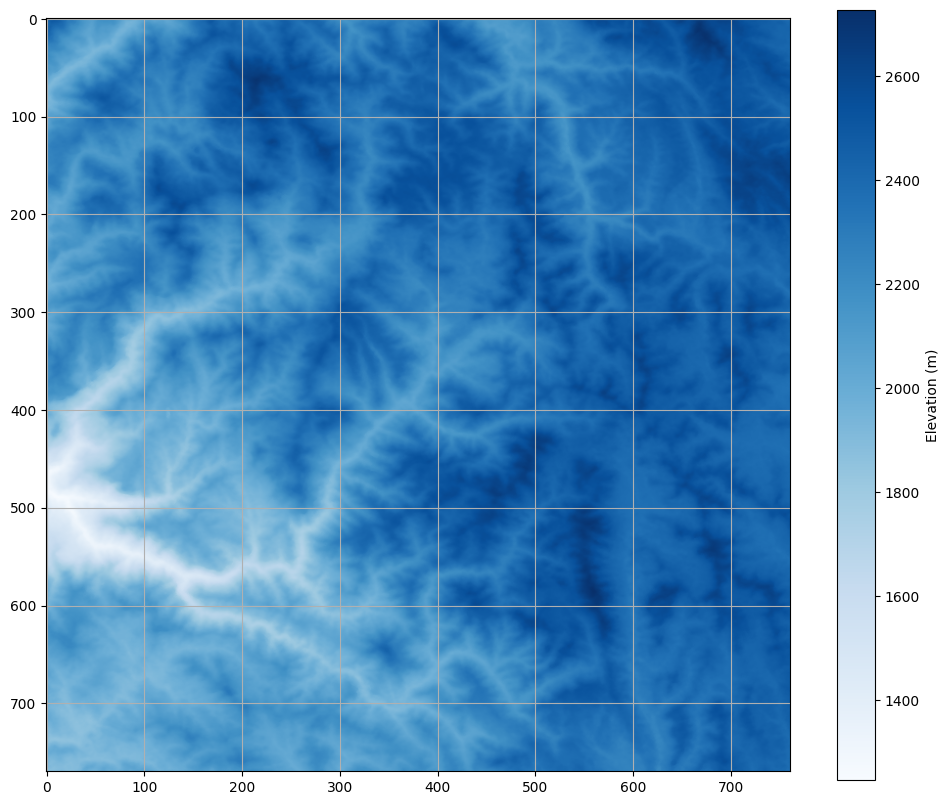

In [2]:
grid = Grid.from_raster('../Rst/20190109125130_1063922483.tif')
dem = grid.read_raster('../Rst/20190109125130_1063922483.tif')

# Visualizar el DEM
def plotFigure(data, label, cmap='Blues'):
    plt.figure(figsize=(12, 10))
    plt.imshow(data, cmap=cmap)
    plt.colorbar(label=label)
    plt.grid()

# Acceder a los datos del DEM correctamente
plotFigure(dem[:-1, :-1], 'Elevation (m)')

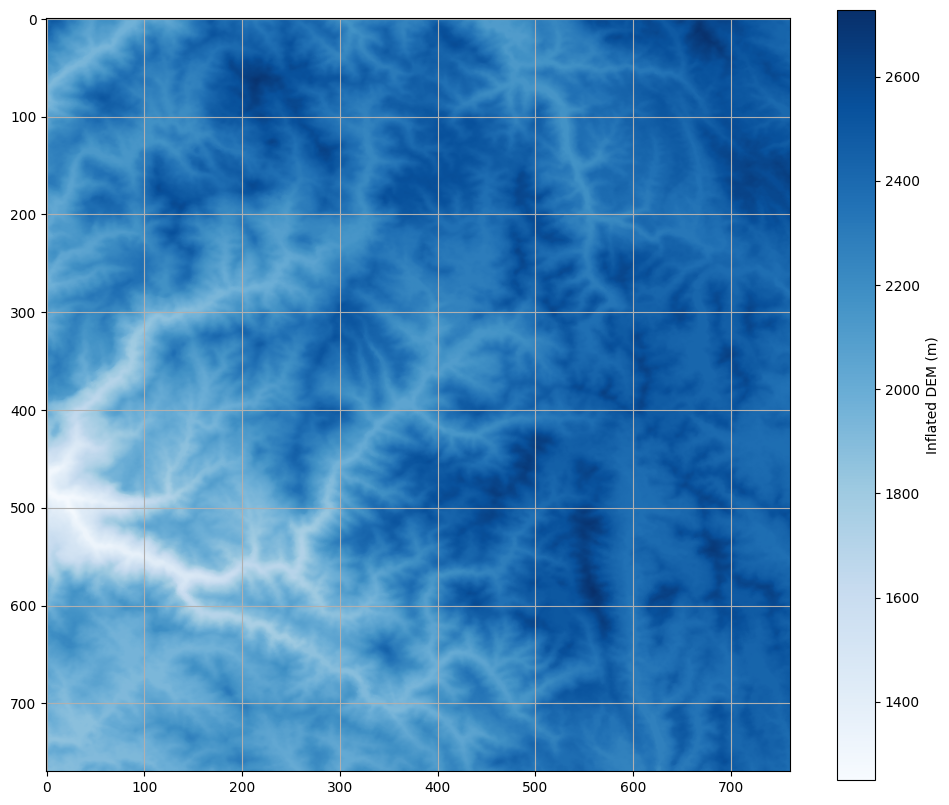

In [3]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)


plotFigure(inflated_dem[:-1, :-1], 'Inflated DEM (m)')

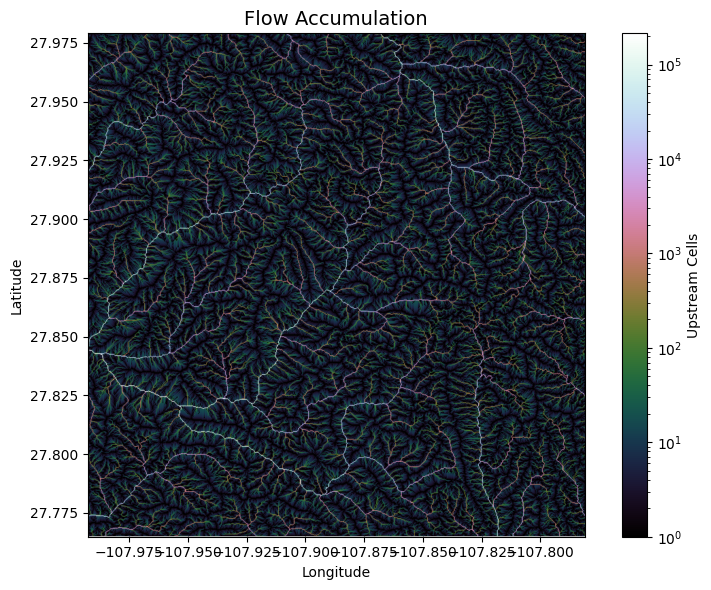

In [4]:
# Determine D8 flow directions from DEM
# ----------------------
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(inflated_dem, dirmap=dirmap, )

# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir, dirmap=dirmap)


fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(acc, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()),
               interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Upstream Cells')
plt.title('Flow Accumulation', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

Text(0.5, 1.0, 'Delineated Catchment')

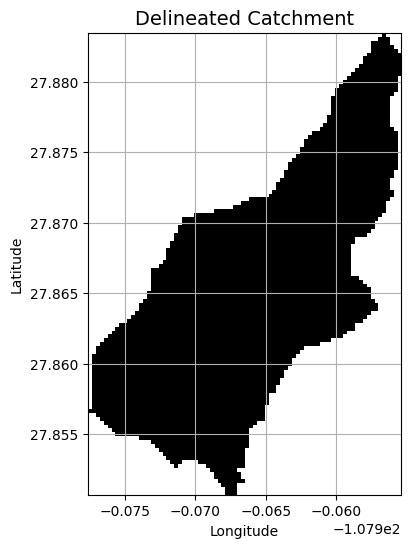

In [5]:
# Delineate a catchment
# ---------------------
# Specify pour point
x, y = -107.975, 27.850

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                       xytype='coordinate')

# Crop and plot the catchment
# ---------------------------
# Clip the bounding box to the catchment
grid.clip_to(catch)
clipped_catch = grid.view(catch)

# Plot the catchment
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.grid('on', zorder=0)
im = ax.imshow(np.where(clipped_catch, clipped_catch, np.nan), extent=grid.extent,
               zorder=1, cmap='Greys_r')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Delineated Catchment', size=14)

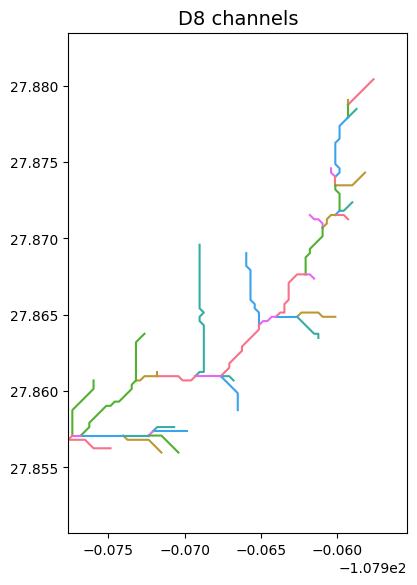

In [6]:
# Extract river network
# ---------------------
import seaborn as sns
branches = grid.extract_river_network(fdir, acc > 50, dirmap=dirmap)
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)

Text(0.5, 1.0, 'Flow Distance')

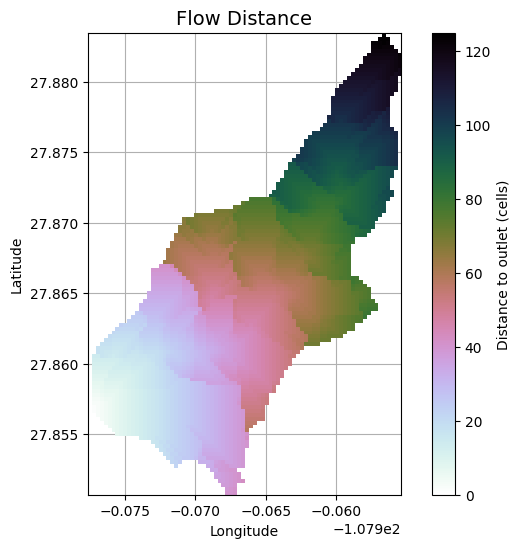

In [7]:
# Calculate distance to outlet from each cell
# -------------------------------------------
dist = grid.distance_to_outlet(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap,
                               xytype='coordinate')
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(dist, extent=grid.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

In [8]:
grid = Grid.from_raster('../Rst/20190109125130_1063922483.tif', data_name='dem')
dem = grid.read_raster('../Rst/20190109125130_1063922483.tif', data_name='dem')

In [9]:
type(grid)

pysheds.sgrid.sGrid

In [10]:
type(dem)

pysheds.sview.Raster

In [11]:
dir(grid)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_d8_accumulation',
 '_d8_catchment',
 '_d8_cell_dh',
 '_d8_cell_distances',
 '_d8_compute_hand',
 '_d8_distance_to_ridge',
 '_d8_flow_distance',
 '_d8_flowdir',
 '_dinf_accumulation',
 '_dinf_catchment',
 '_dinf_cell_dh',
 '_dinf_cell_distances',
 '_dinf_compute_hand',
 '_dinf_distance_to_ridge',
 '_dinf_flow_distance',
 '_dinf_flowdir',
 '_get_nodata_cells',
 '_input_handler',
 '_mfd_accumulation',
 '_mfd_catchment',
 '_mfd_cell_dh',
 '_mfd_cell_distances',
 '_mfd_compute_hand',
 '_mfd_distance_to_ridge',
 '_mfd_flow_distance',
 '_mfd_flowdir',
 '_output_handler',
 '_pop_rim',
 '_replace_rim',
 '_viewfi

In [12]:
dir(dem)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul

In [13]:
print(dem)
type(dem)

[[  2447   2462   2474 ...   2394   2402 -32768]
 [  2431   2450   2463 ...   2401   2404 -32768]
 [  2415   2428   2449 ...   2400   2402 -32768]
 ...
 [  1882   1880   1885 ...   2369   2364 -32768]
 [  1878   1880   1883 ...   2367   2365 -32768]
 [-32768 -32768 -32768 ... -32768 -32768 -32768]]


pysheds.sview.Raster

In [14]:
print(dem[:-1,:-1])
type(dem[:-1,:-1])

[[2447 2462 2474 ... 2388 2394 2402]
 [2431 2450 2463 ... 2397 2401 2404]
 [2415 2428 2449 ... 2400 2400 2402]
 ...
 [1893 1893 1894 ... 2382 2377 2371]
 [1882 1880 1885 ... 2373 2369 2364]
 [1878 1880 1883 ... 2371 2367 2365]]


pysheds.sview.Raster

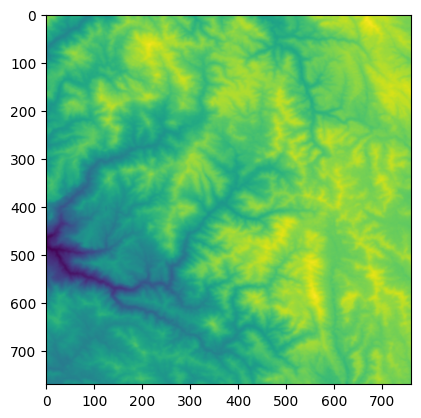

In [15]:
plt.imshow(dem[:-1,:-1])

In [16]:
def plotFigure(data, label, cmap='Blues'):
    plt.figure(figsize=(12,10))
    plt.imshow(data, extent=grid.extent)
    plt.colorbar(label=label)
    plt.grid()

In [17]:
elevDem= dem[:-1,:-1]

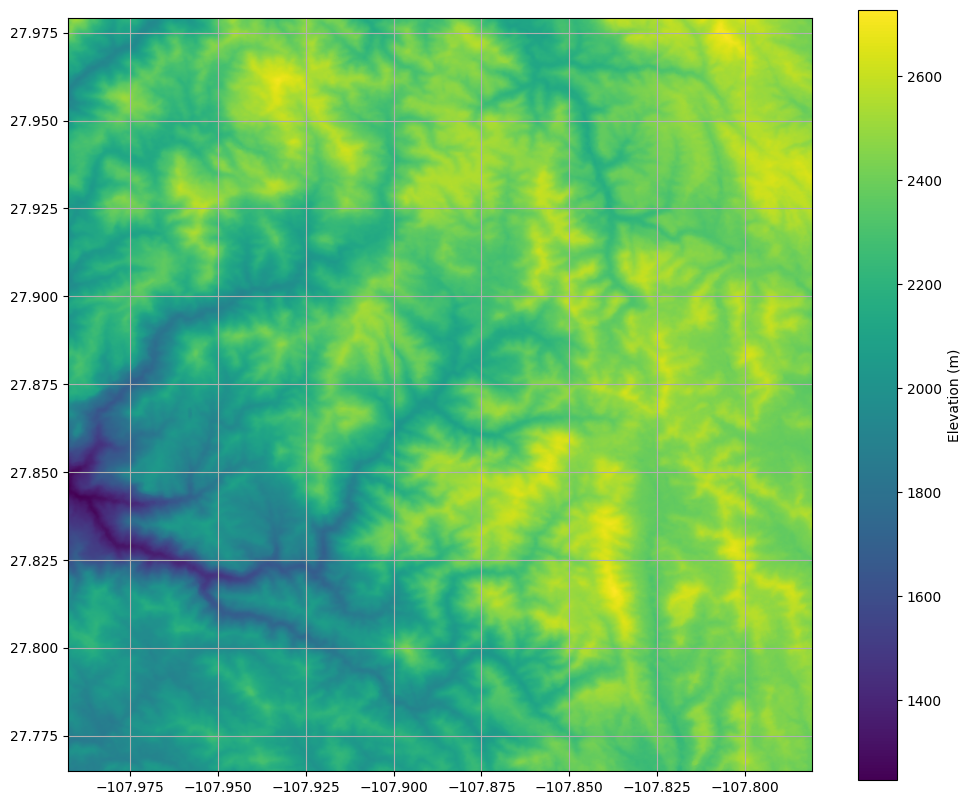

In [18]:
plotFigure(elevDem, 'Elevation (m)')

In [19]:
### Detecting depressions

# Detect depressions
sdepressions = grid.detect_depressions(dem)

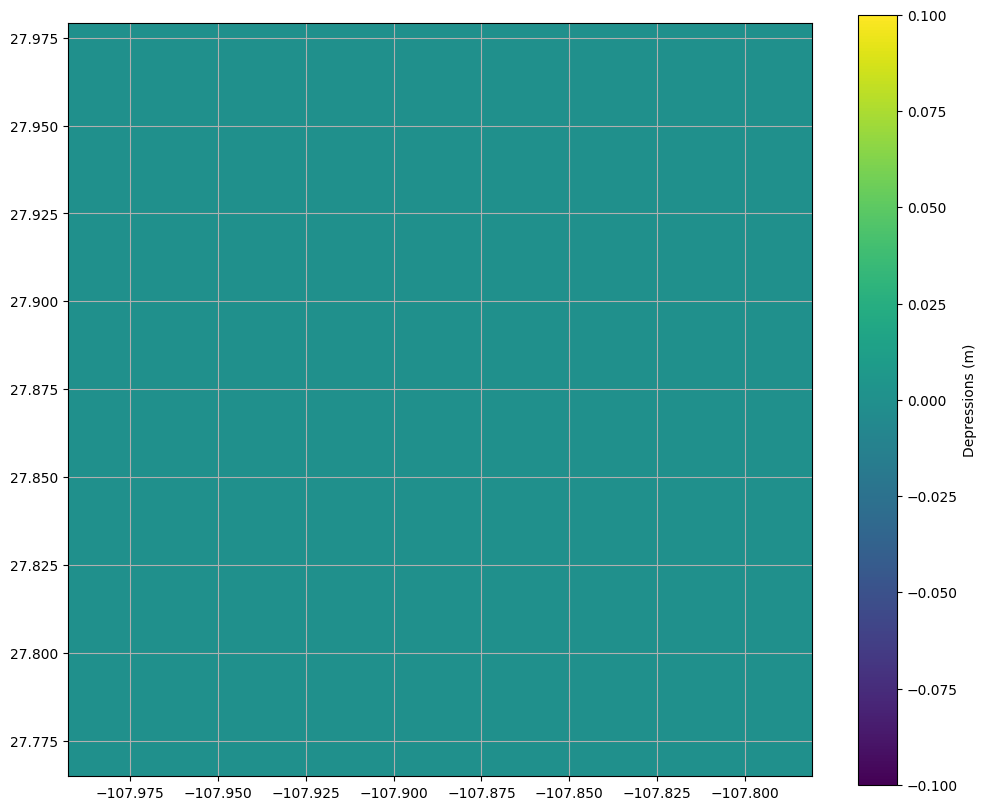

In [20]:
# Plot depressions
plotFigure(sdepressions[:-1,:-1], 'Depressions (m)')

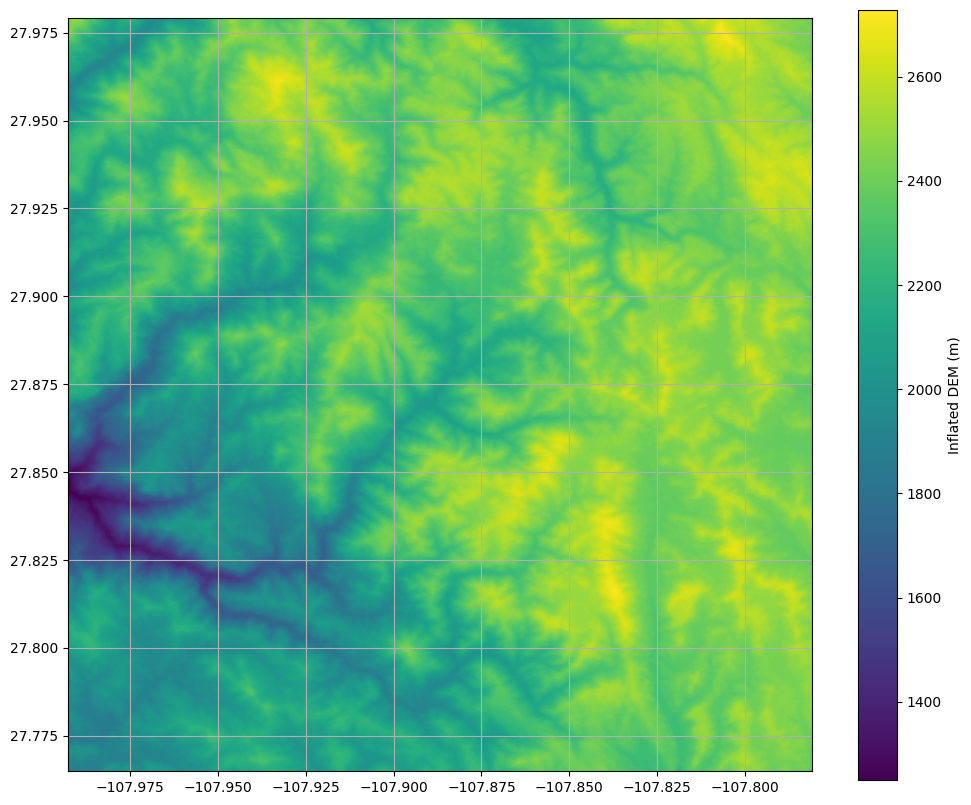

In [21]:
# Condition DEM
# ----------------------
# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)


plotFigure(inflated_dem[:-1, :-1], 'Inflated DEM (m)')

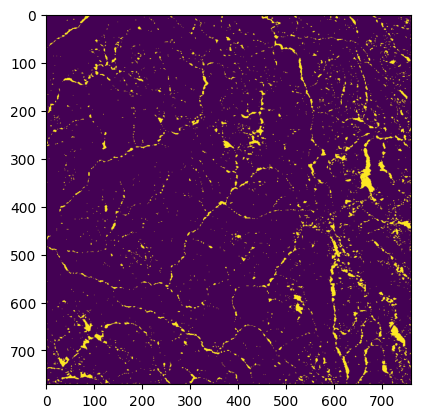

In [22]:
# Detect flats
flats = grid.detect_flats(flooded_dem)

# Plot flats
plt.imshow(flats)

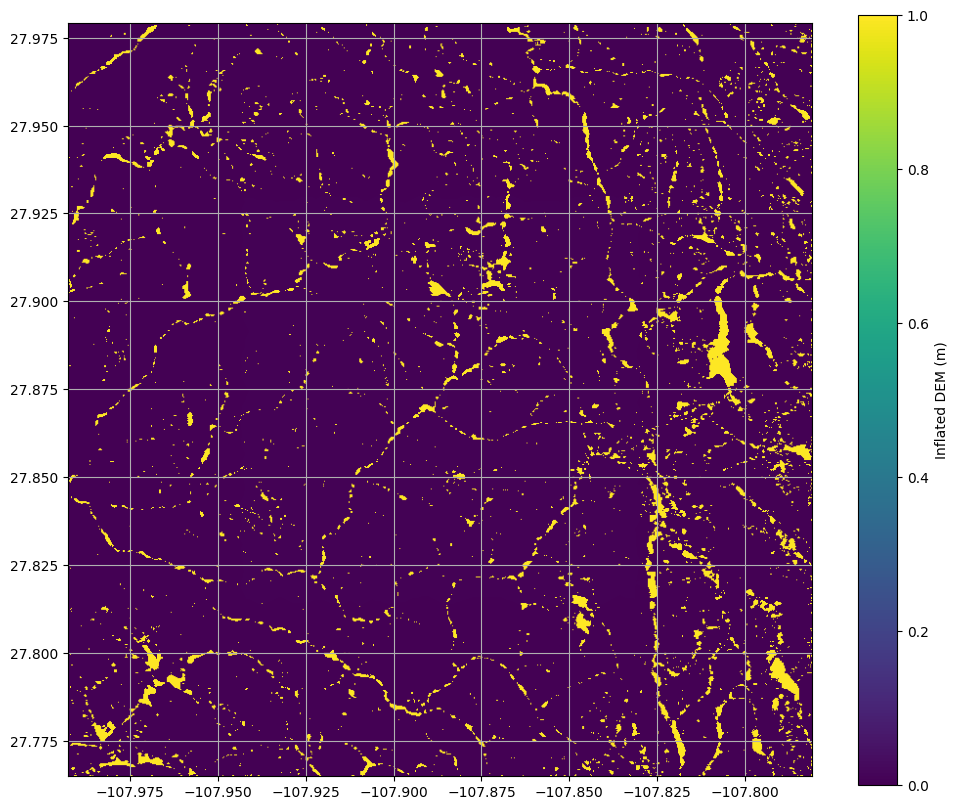

In [23]:
newflats = grid.resolve_flats(flats)
plotFigure(newflats[:-1, :-1], 'Inflated DEM (m)')

In [24]:
fdir = grid.flowdir(inflated_dem)

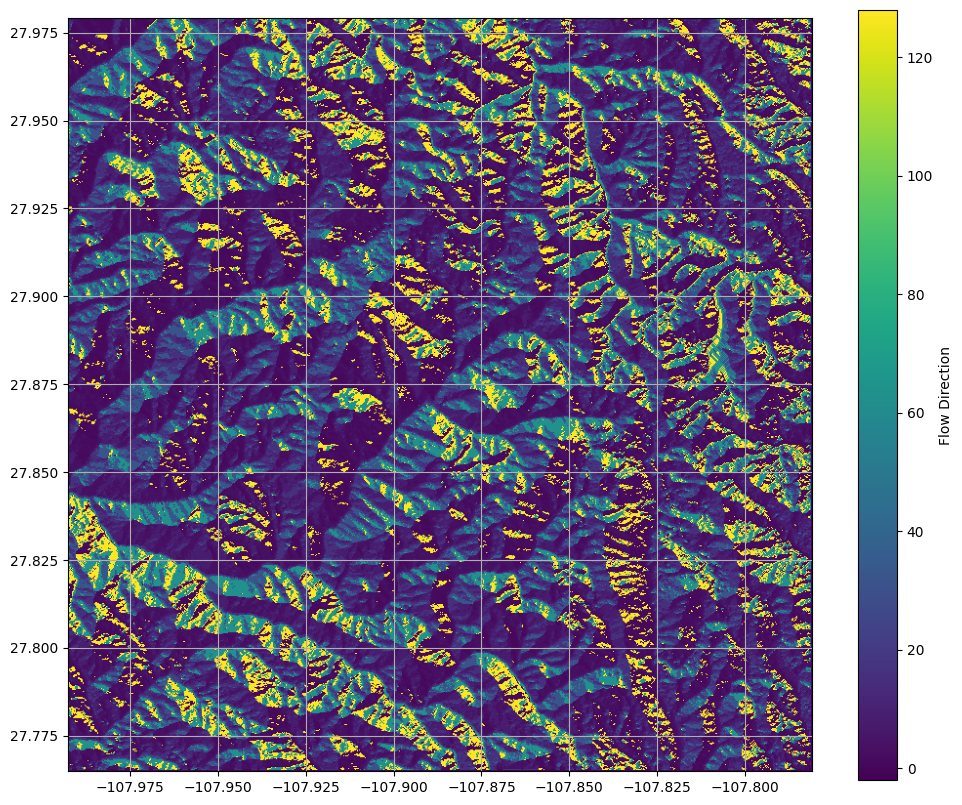

In [25]:
plotFigure(fdir,'Flow Direction','viridis')

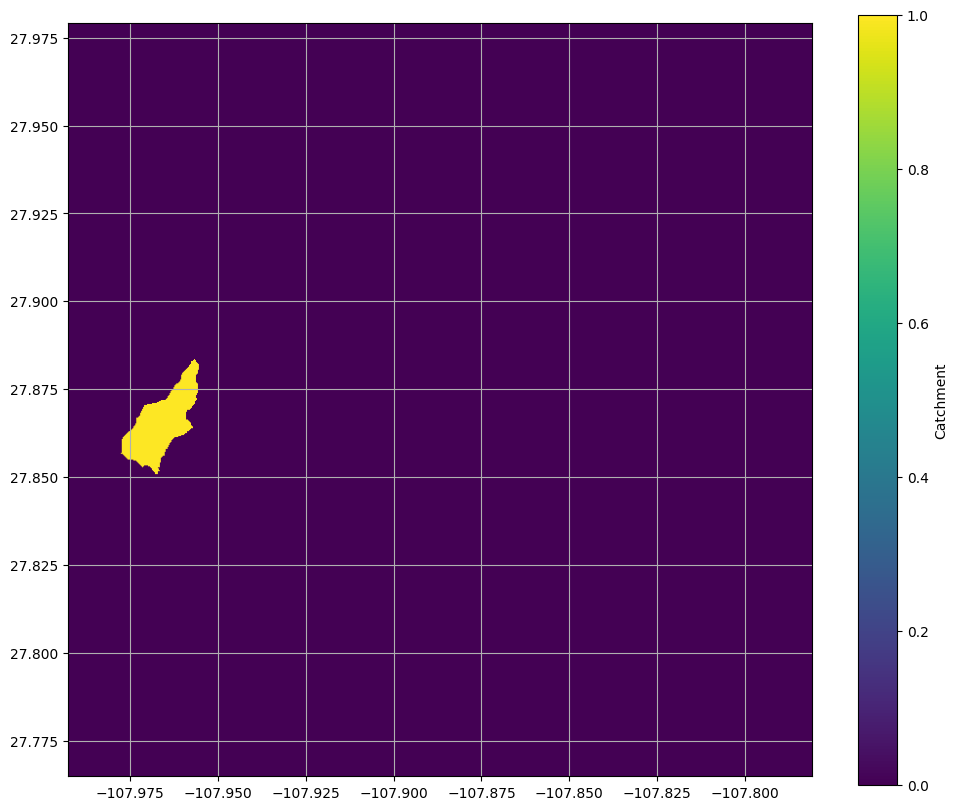

In [26]:
# Specify pour point
x, y = -107.975, 27.850

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch2 = grid.catchment(fdir=fdir, x=x_snap, y=y_snap, recursionlimit=15000, xytype='coordinate', nodata_out=0)
plotFigure(catch2, 'Catchment', 'Greys_r')

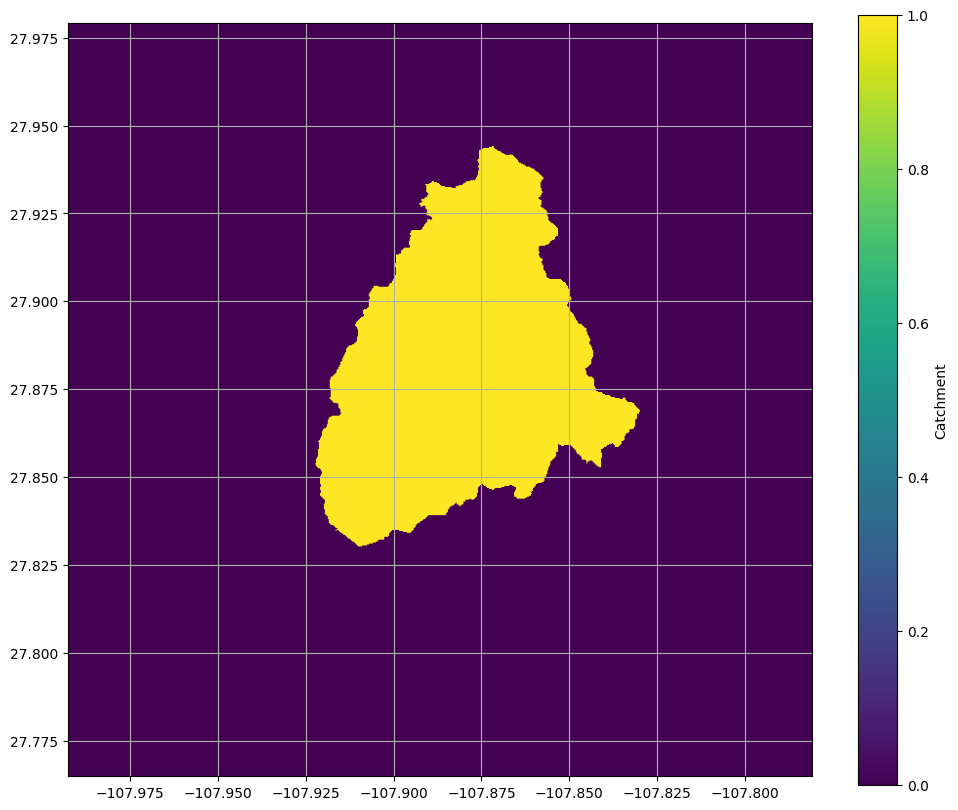

In [27]:
# Specify discharge point
x, y = -107.91663,27.83479

# Delineate the catchment
catch = grid.catchment(fdir=fdir, x=x, y=y, recursionlimit=15000, xytype='label', nodata_out=0)
plotFigure(catch, 'Catchment', 'Greys_r')

In [28]:
# Crop and plot the catchment
# ---------------------------
# Clip the bounding box to the catchment
grid.clip_to(catch)

Text(0.5, 1.0, 'Delineated Catchment')

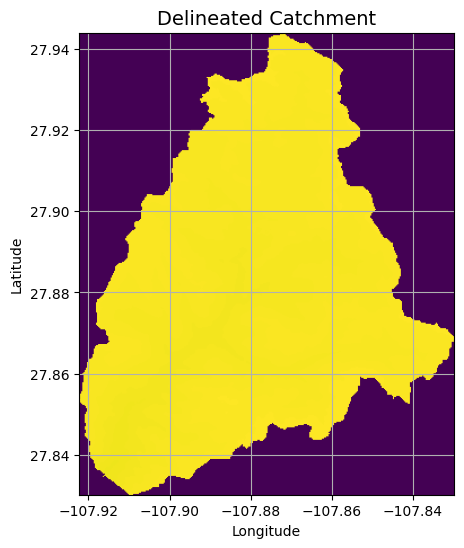

In [29]:
# Get a view of the catchment
clipped_catch = grid.view(elevDem)

# Plot the catchment
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.grid('on', zorder=0)
im = ax.imshow(np.where(clipped_catch, clipped_catch, np.nan), extent=grid.extent,
               zorder=1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Delineated Catchment', size=14)

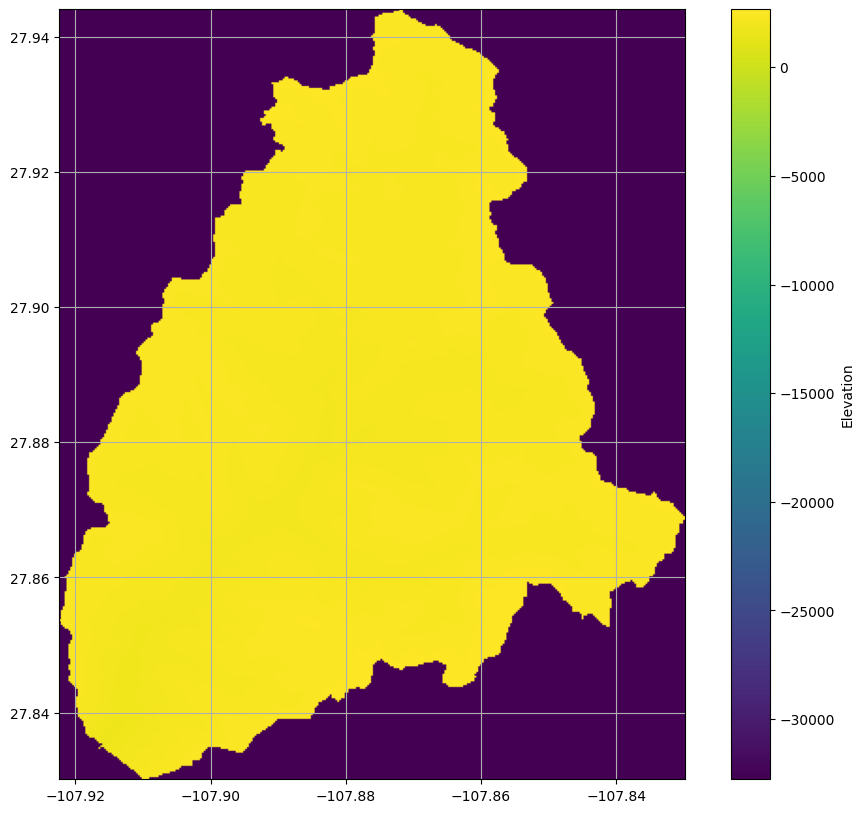

In [30]:
plotFigure(clipped_catch,'Elevation')

In [31]:
#export selected raster
grid.to_raster(demView, '../Output/clippedElevations.tif')

NameError: name 'demView' is not defined

Text(0.5, 1.0, 'Flow Distance')

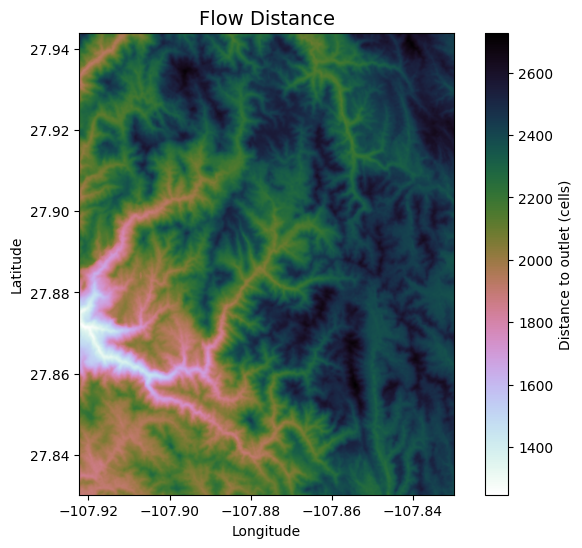

In [47]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(elevDem, extent=clipped_catch.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

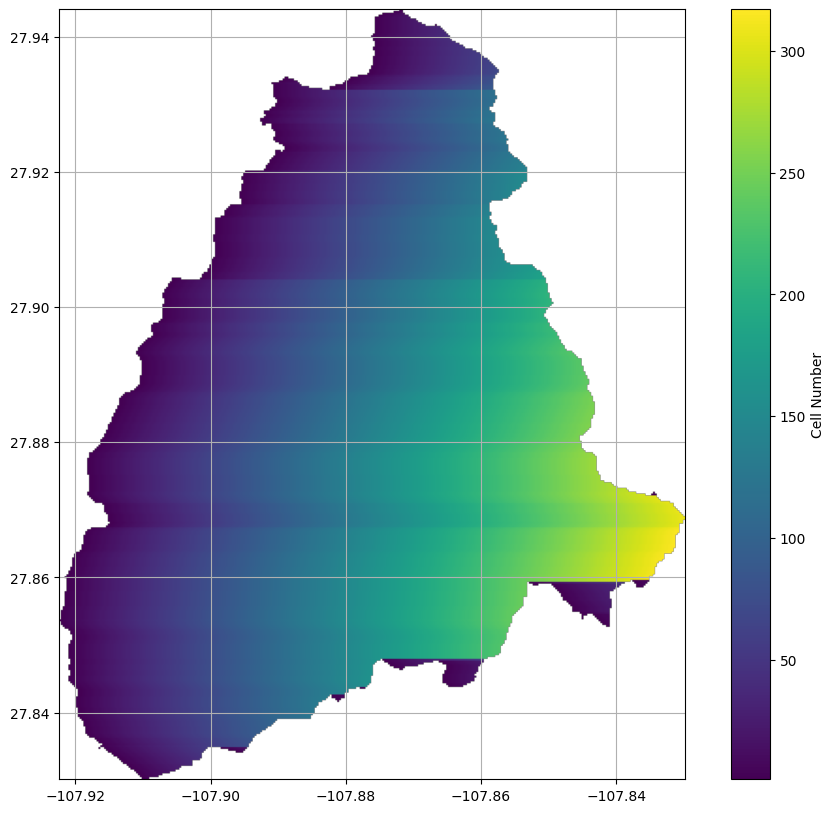

In [43]:
accCatch = grid.accumulation(catch, dirmap=dirmap, pad_inplace=False)
accView = grid.view(accCatch, nodata=np.nan)
plotFigure(accView,"Cell Number",'PuRd')

In [ ]:
streams = grid.extract_river_network('catch', 'acc', threshold=200, dirmap=dirmap)
streams["features"][:2]

[{"geometry": {"coordinates": [[-107.86763888888879, 27.93319444444552], [-107.86763888888879, 27.933472222223298], [-107.86763888888879, 27.933750000001073], [-107.86791666666657, 27.93402777777885], [-107.86791666666657, 27.93430555555663], [-107.86791666666657, 27.93458333333441], [-107.86791666666657, 27.934861111112188], [-107.86791666666657, 27.935138888889963], [-107.86791666666657, 27.93541666666774], [-107.86791666666657, 27.93569444444552], [-107.86791666666657, 27.9359722222233], [-107.86763888888879, 27.936250000001078], [-107.86763888888879, 27.936527777778853], [-107.86736111111101, 27.93680555555663], [-107.86736111111101, 27.93708333333441], [-107.86708333333324, 27.93736111111219], [-107.86708333333324, 27.937638888889968], [-107.86708333333324, 27.937916666667743], [-107.86708333333324, 27.93819444444552], [-107.86736111111101, 27.9384722222233], [-107.86736111111101, 27.93875000000108], [-107.86763888888879, 27.939027777778858], [-107.86763888888879, 27.9393055555566

In [ ]:
def saveDict(dic,file):
    f = open(file,'w')
    f.write(str(dic))
    f.close()

In [ ]:
#save geojson as separate file
saveDict(streams,'../Output/streams_WGS84.geojson')

In [ ]:
streamNet = gpd.read_file('../Output/streams_WGS84.geojson')
streamNet.crs = {'init' :'epsg:4326'}

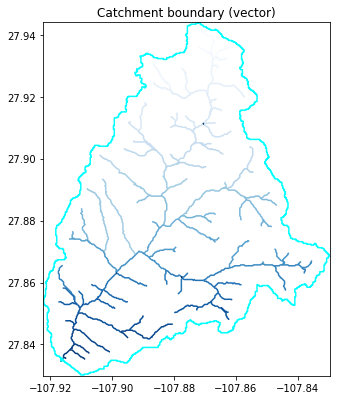

In [ ]:
# The polygonize argument defaults to the grid mask when no arguments are supplied
shapes = grid.polygonize()

# Plot catchment boundaries
fig, ax = plt.subplots(figsize=(6.5, 6.5))

for shape in shapes:
    coords = np.asarray(shape[0]['coordinates'][0])
    ax.plot(coords[:,0], coords[:,1], color='cyan')
    
ax.set_xlim(grid.bbox[0], grid.bbox[2])
ax.set_ylim(grid.bbox[1], grid.bbox[3])
ax.set_title('Catchment boundary (vector)')
gpd.plotting.plot_dataframe(streamNet, None, cmap='Blues', ax=ax)

In [ ]:
#ax = streamNet.plot()
mplleaflet.display(fig=ax.figure, crs=streamNet.crs, tiles='esri_aerial')